In [4]:
import pandas as pd
import oscfar as ocf

np = ocf.np
from IPython.display import Image
from pathlib import Path

import sys

In [23]:
%matplotlib inline

In [3]:
import subprocess, pyperclip

In [8]:
import paths as p

sys.path.insert(0, p.DM_PHASE_PATH)
sys.path.insert(0, p.BASEBAND_ANALYSIS_PATH)
sys.path.insert(0, "fitburst")

import methods as m
import sheets as s
from plotting import plot_event, plt

### Load event


In [189]:
eid = 203320711
n_peaks = 1

In [190]:
s.pandas.DataFrame([s.get_info(eid)])[['EventID', 'Status', 'Path', 'Ran by', 'Alice-Ketan', 'Components A-K', 'Source', 'Set', 'Eyeballed Components', 'Easy to fit?']]

,EventID,Status,Path,Ran by,Alice-Ketan,Components A-K,Source,Set,Eyeballed Components,Easy to fit?
0,203320711,Preparing npz file,/arc/projects/chime_frb,clegue,,,SideCat,SideCat,,


In [191]:
s.pandas.DataFrame([s.get_info(eid, "Prioritized Events")])[['Event ID', 'Data Set', 'Downsampling', 'To rerun?', 'Last fitburst timestamp', 'Notes timestamp', 'Notes', 'Notes R2', 'Rerun Notes']]

,Event ID,Data Set,Downsampling,To rerun?,Last fitburst timestamp,Notes timestamp,Notes,Notes R2,Rerun Notes
0,203320711,SideCat,,,,,,,


Plotting /home/chujo/Desktop/Research/fitbursting/npz/203320711.npz..
Using 14 for title and 16 for labels.


/home/chujo/Desktop/Research/fitbursting/plotting.py:226: RuntimeWarning: Mean of empty slice
  on_spec = np.nanmean(


(1024, 2329)
14.3300608 0.4927512284671223
2D Spectrum range
Time range: -9.04192 to 14.80704
Frequency range: 400.1953125 to 800.1953125


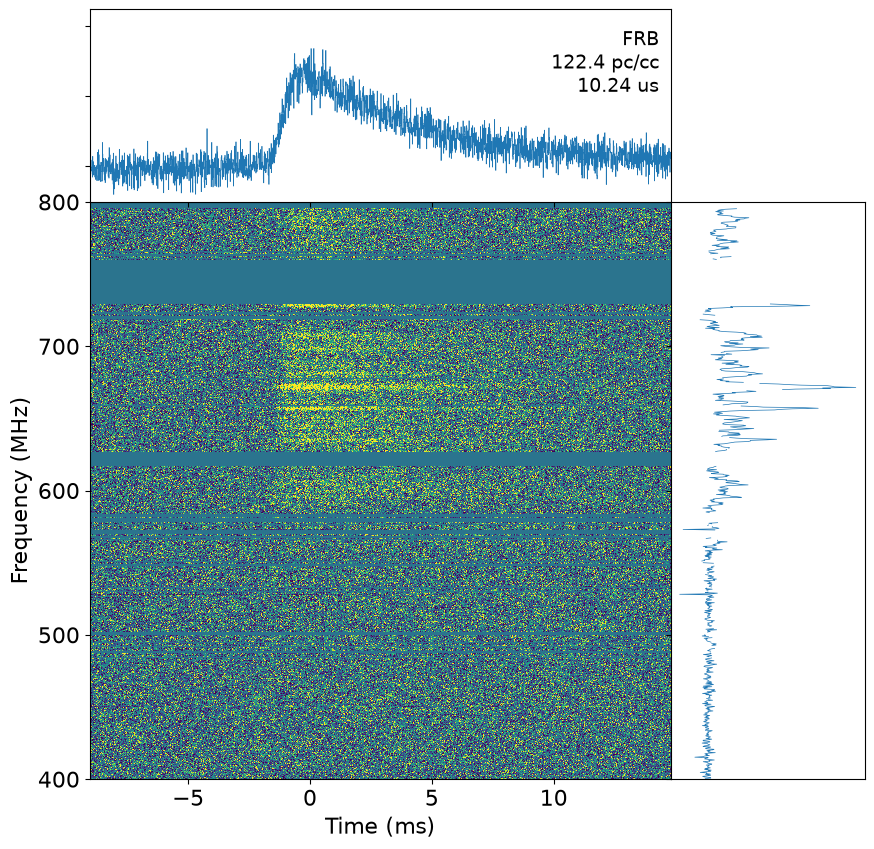

In [192]:
npz = plot_event(eid, tns_override="FRB")
plt.show()

### Find peaks


In [193]:
profile = m.get_profile(npz.data_full)

1.622344122334169
Best_frac being used is and the flag is 0.024335161835012536 True
Iteration 1: Smoothing the data and finding the peaks...
Number of peaks found 1
Iteration 2: Smoothing the data and finding the peaks...
Number of peaks found 1
Lowess smoothing fraction used: 0.024335161835012536
Prominence cutoff used:  0.1
Peaks:  [859]
Peaks*time resolution:  [0.00879616]
Prominences of peaks:  [8.2]
Heights of the peaks:  [8.27840665]


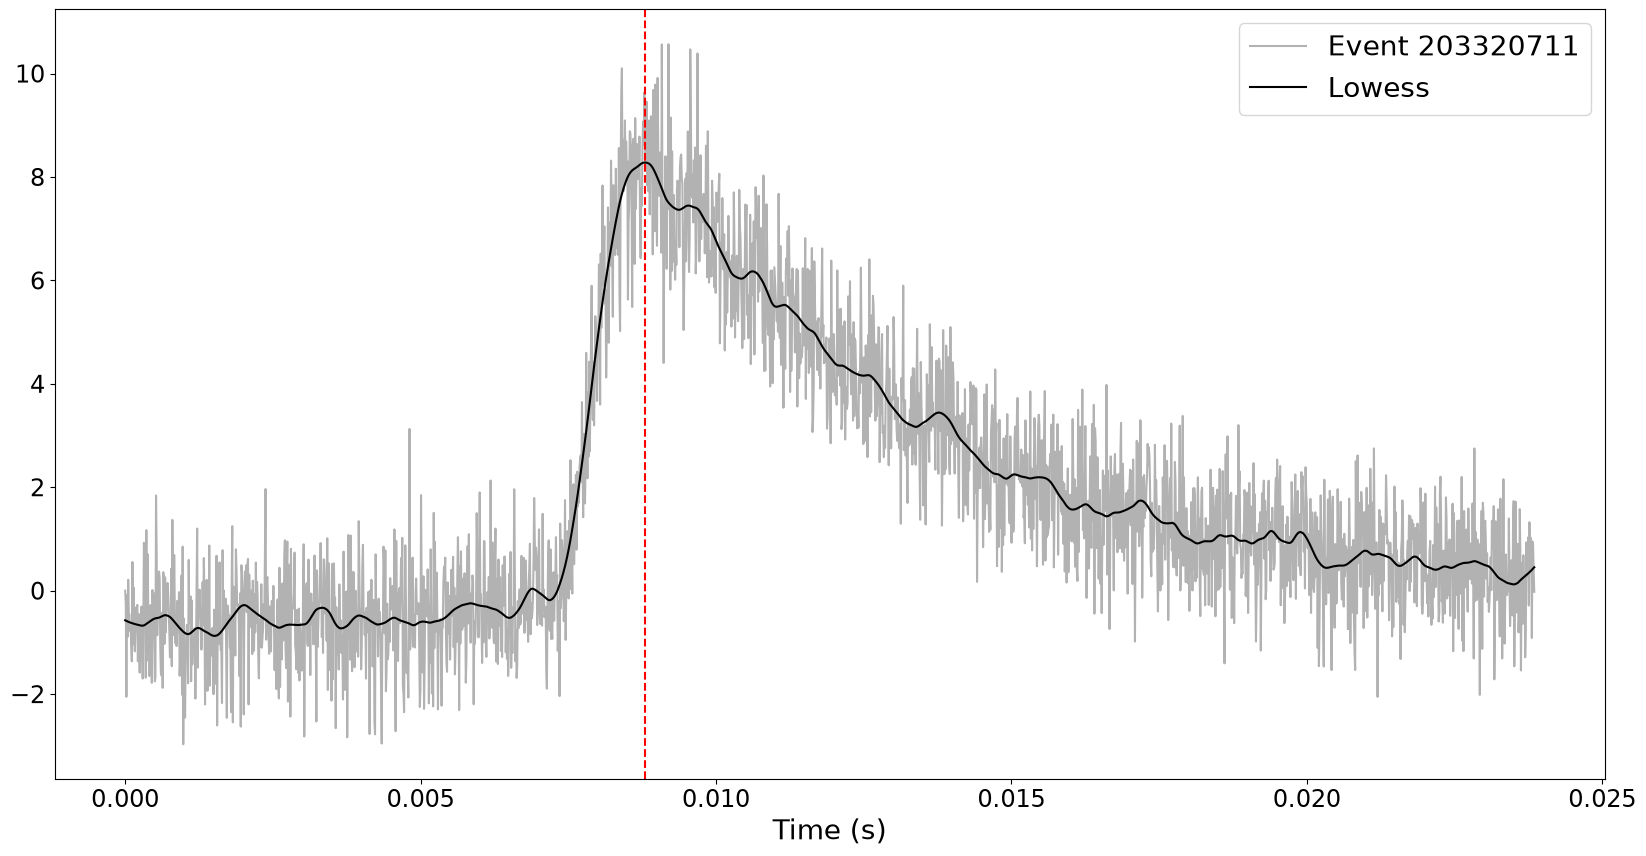

In [194]:
peaks, heights = m.get_peaks(
    profile, npz.res_time, True, l=0.1, event_id=str(eid), n_peaks=n_peaks
)

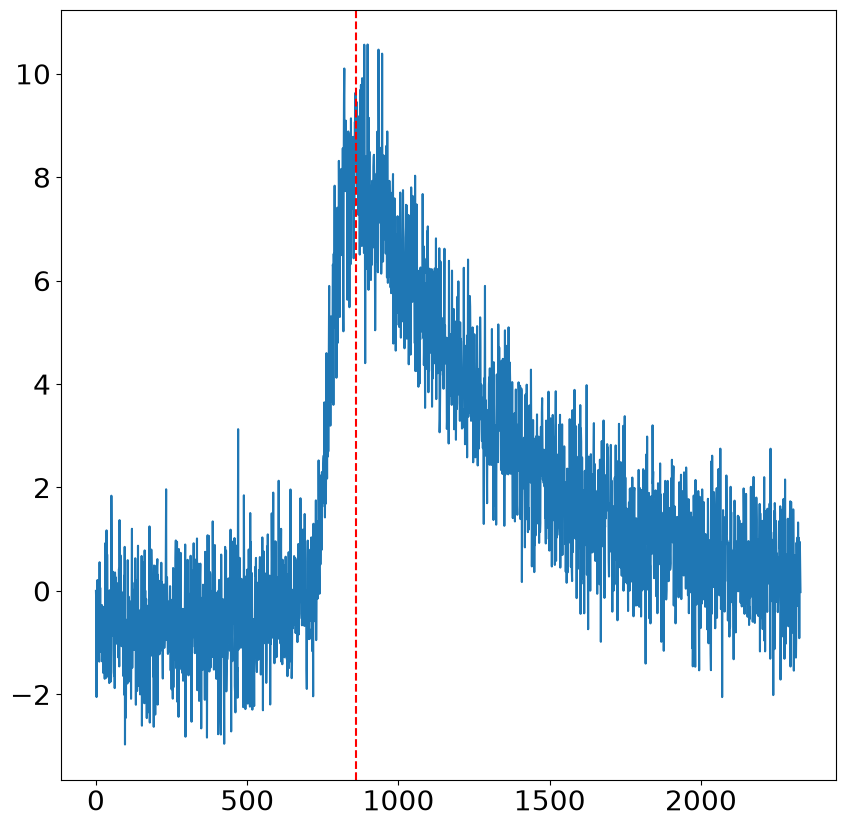

In [195]:
# peaks = [667, 750, 500]
plt.plot(profile)
for x in peaks:
    plt.axvline(x, ls="--", c="red")

peaks = np.array(peaks)
heights = profile[peaks]

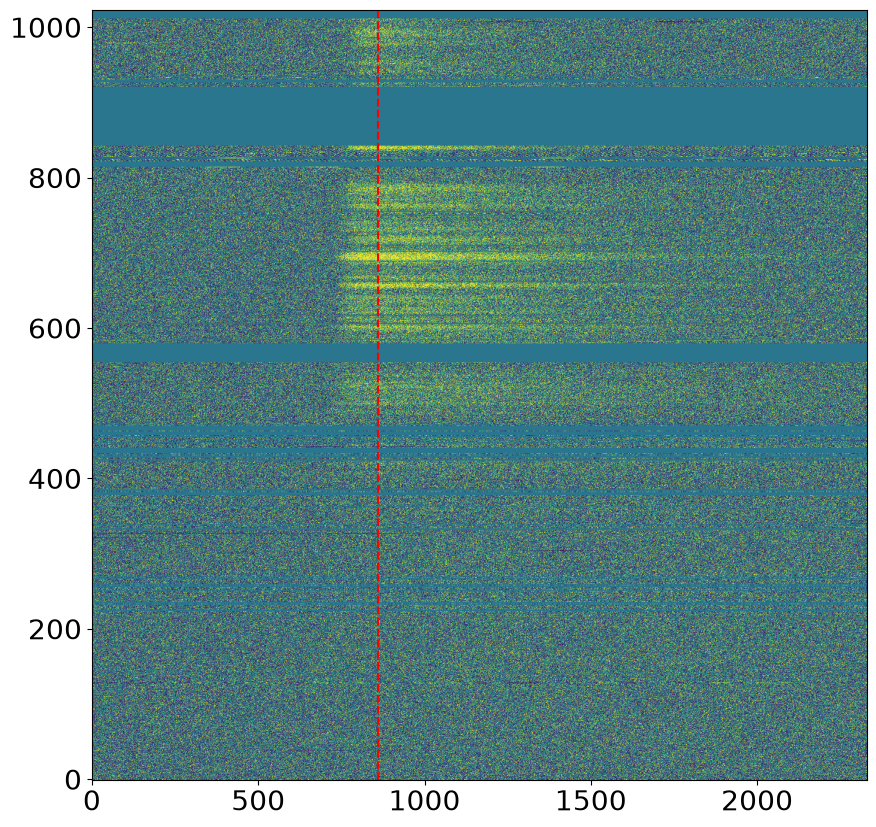

In [196]:
plt.imshow(
    npz.data_full,
    origin="lower",
    vmin=np.percentile(npz.data_full, 5),
    vmax=np.percentile(npz.data_full, 95),
)
for peak in peaks:
    plt.axvline(peak, c="red", ls="--")

### Fit peaks


Adjust the `min_width` until you get a nice LS fit.

2026-09-16 15:03:47,833 - INFO - Plotting the profile in blue, the initial fit guess in orange, and the peak in red


Initial guesses [np.float64(0.049091591323414736), np.float64(0.00879616), np.float64(5e-05), 0.0001]

Upper bounds [np.float64(inf), np.float64(0.00884616), np.float64(0.0238592), inf]

lower bounds [np.float64(0.0), np.float64(0.008746160000000001), np.float64(0.0), 0]


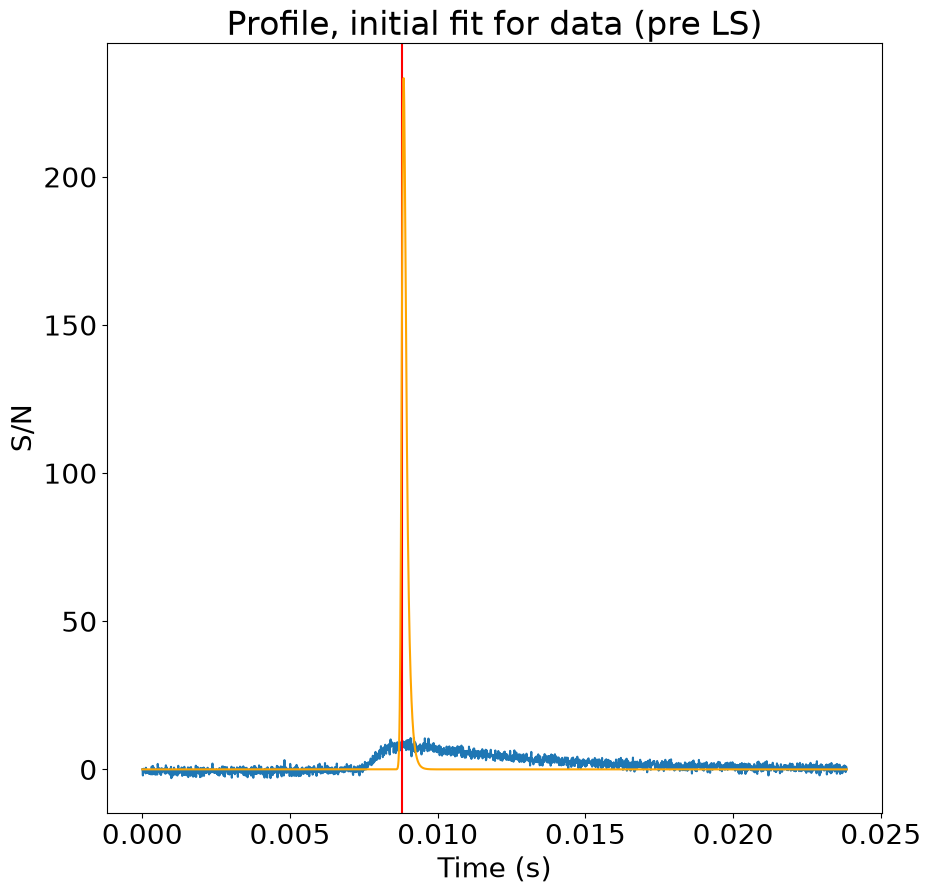

2026-09-16 15:03:48,877 - INFO - Now doing a curve_fit for the initial fit function to the data
2026-09-16 15:03:48,878 - INFO - Using bounds: ([np.float64(0.0), np.float64(0.008746160000000001), np.float64(0.0), 0], [np.float64(inf), np.float64(0.00884616), np.float64(0.0238592), inf])
2026-09-16 15:03:48,888 - INFO - Now plotting the results of the curve fit


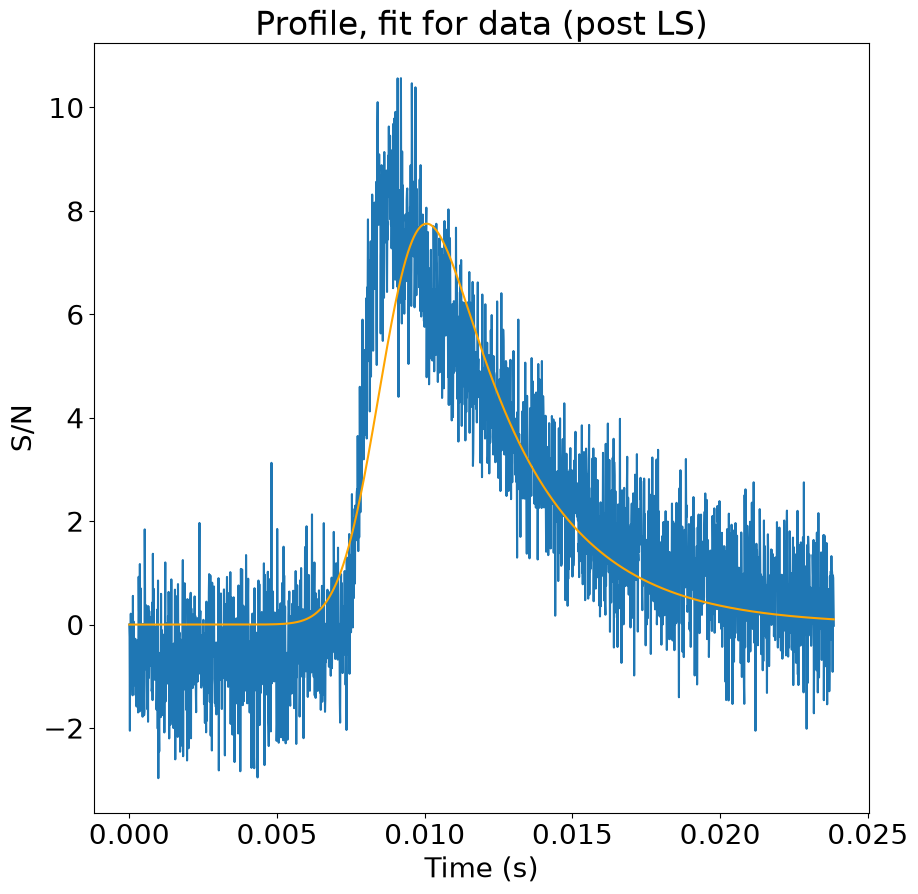

2026-09-16 15:03:48,985 - INFO - Curve_fit params: [0.04317565 0.00874616 0.00114926 0.00300552]


MEAN [0.00874616]
Reduced Chi Squared for Event X is 2.39
Fit of model to profile & residuals


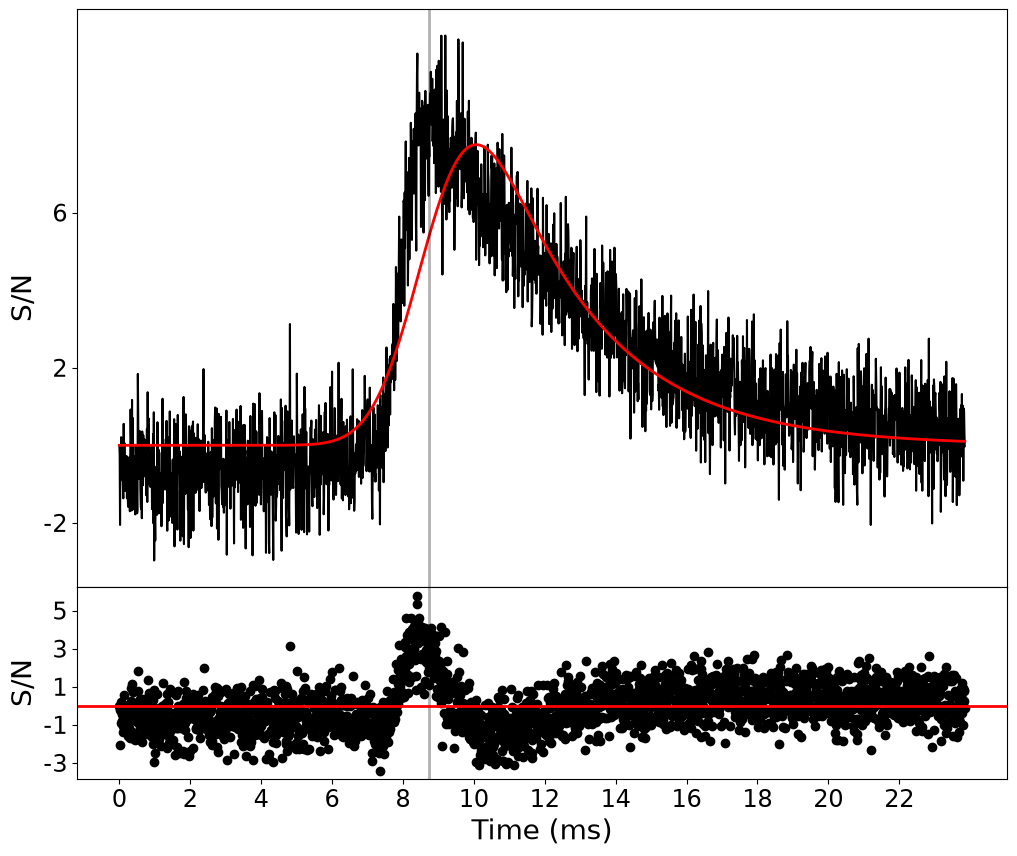

Below is a Q-Q plot of the residuals vs. that expected from a standard normal distribution.


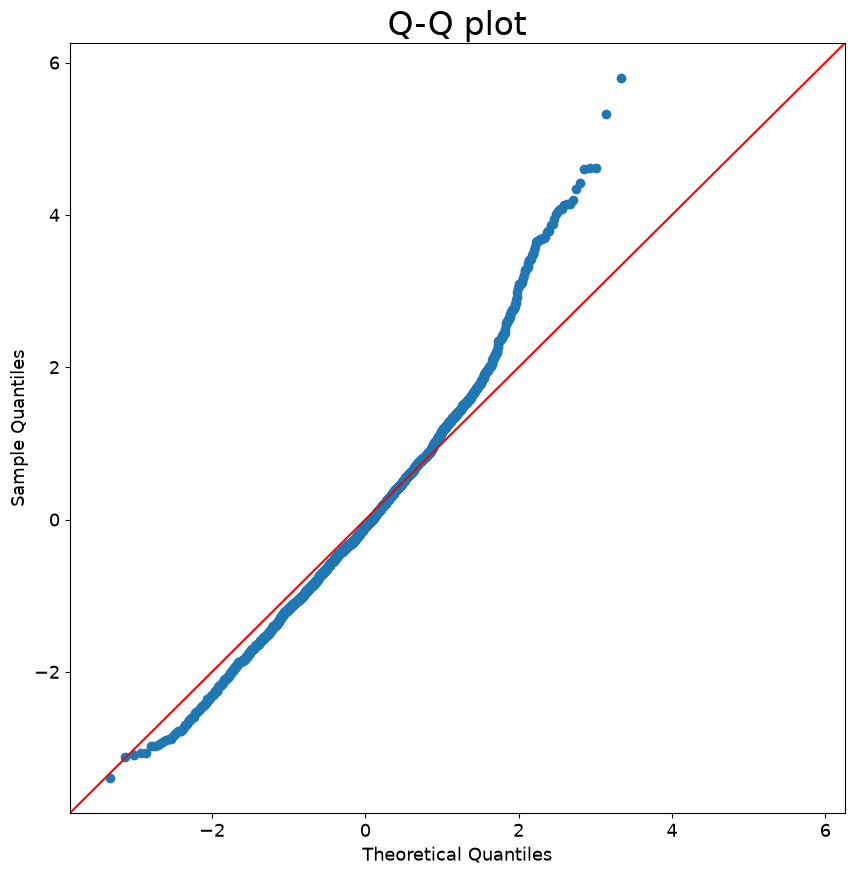

In [197]:
fit, best_params, best_err, cov_mat = m.initial_guess_LS(
    profile, peaks, npz.res_time, heights, min_width=0.00005
)

Max peaks is [0.00879616]
Peaks are [0.00874616]


100%|██████████| 10000/10000 [00:45<00:00, 220.35it/s]


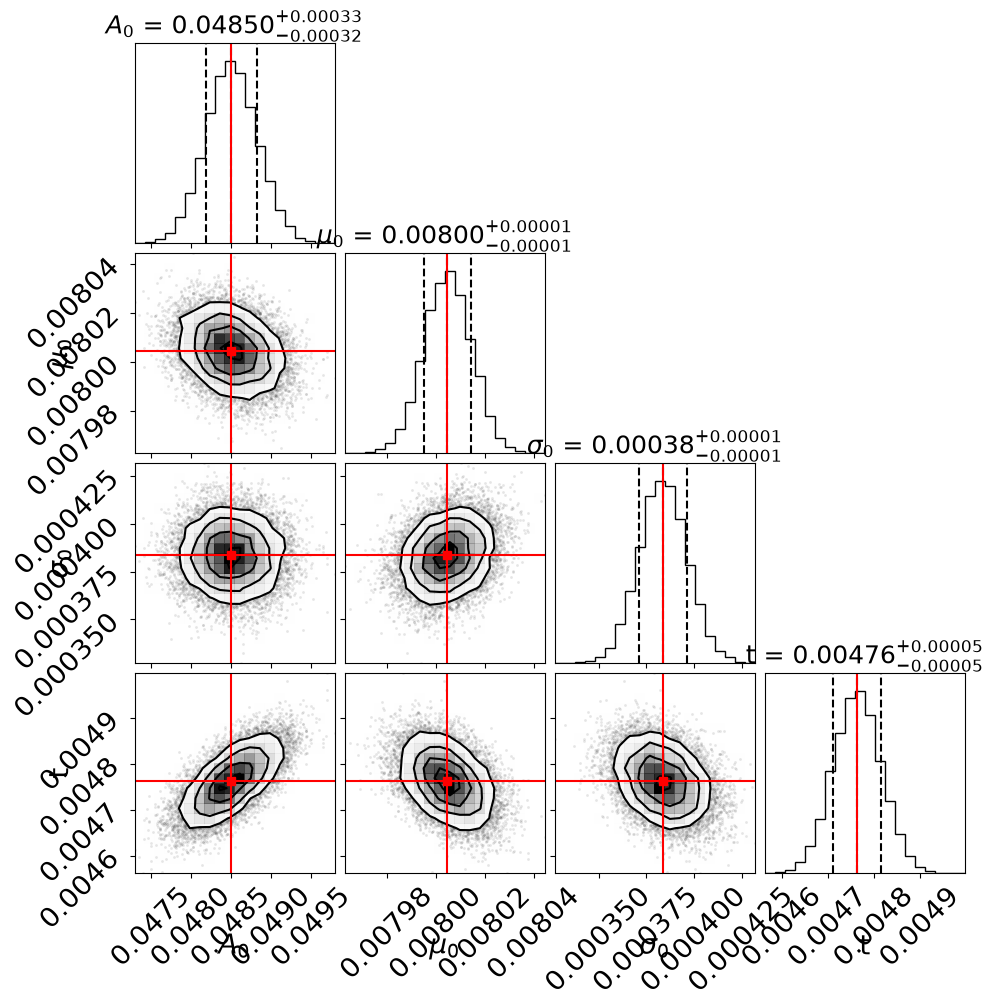

 Below, see the profile fit with the final_pars.
MEAN [0.00800465]
Reduced Chi Squared for Event 203320711 is 0.933
Fit of model to profile & residuals


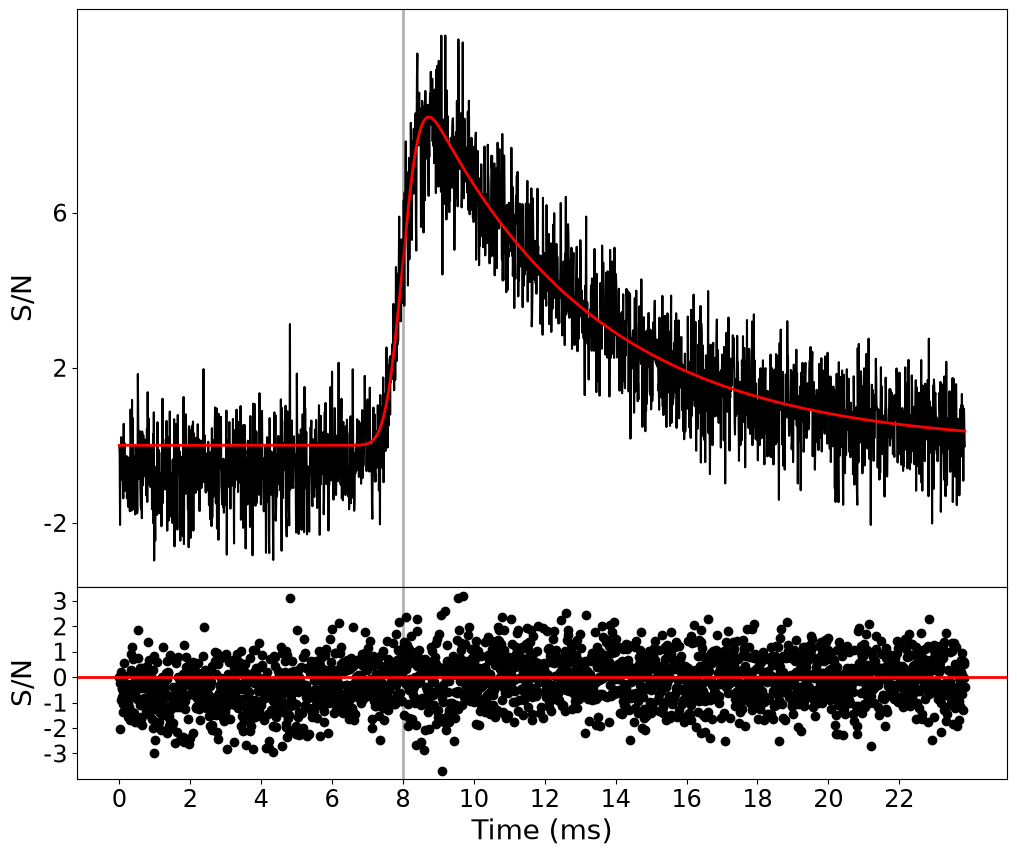

Below is a Q-Q plot of the residuals vs. that expected from a standard normal distribution.


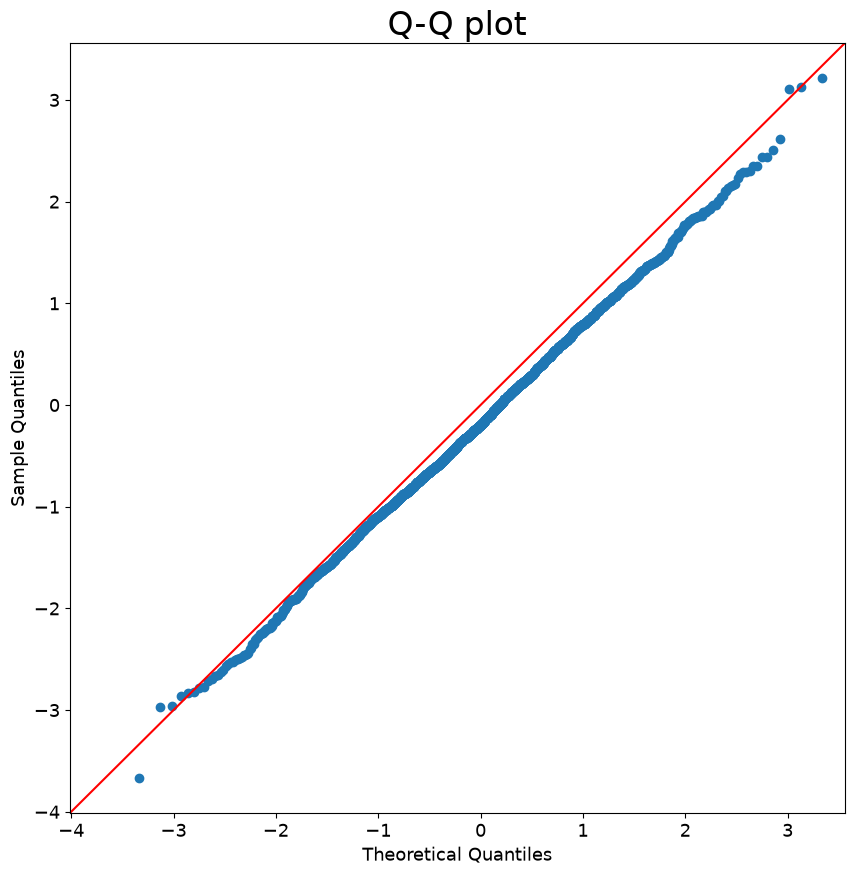

In [198]:
best_params_mcmc, best_err_mcmc = m.initial_guess_mcmc(
    best_params, profile, npz.res_time, int(eid), peaks, nchain=10000, nwalkers=75
)

### Prepare output


In [199]:
params_to_use = best_params_mcmc
params, scattering = np.array(params_to_use[:-1]), params_to_use[-1]
n = int(len(params) / 3)
params = params.reshape((n, 3))  # Each peak has 3 params: amp, mu, sigma

amplitudes = params[:, 0].tolist()
toa = params[:, 1].tolist()
widths = params[:, 2].tolist()

In [200]:
writer = ocf.npz_writer(npz)

In [201]:
def get_dm_back(reader: ocf.npz_reader, writer: ocf.npz_writer):
    if isinstance(reader.burst_parameters["dm"], list):
        # Check if the list is empty, if yes just set back to the metadata value:
        if not reader.burst_parameters["dm"]:
            return reader.metadata["dm"]

        # Otherwise get the "0th" value
        return reader.burst_parameters["dm"][0]

In [202]:
writer.update_burst_parameters(
    amplitude=amplitudes,
    arrival_time=toa,
    burst_width=widths,
    scattering_timescale=[scattering] * n,
    dm=[get_dm_back(npz, writer)] * n,
)

In [203]:
print(f"\033[91mUpdated burst parameters for event ID {eid} in the npz file:\033[0m")
m.show_dict_diff(npz.burst_parameters, writer.burst_parameters)

Updated burst parameters for event ID 203320711 in the npz file:
amplitude: [1] --> [0.04849955149005131]
arrival_time: [0] --> [0.008004645015078336]
burst_width: [0.0001] --> [0.0003836441211194822]
scattering_timescale: [0.0001] --> [np.float64(0.00476201686910469)]


In [204]:
writer.save(npz.file_path)

Saving file at /home/chujo/Desktop/Research/fitbursting/npz/203320711.npz...
Saved file at /home/chujo/Desktop/Research/fitbursting/npz/203320711.npz successfully.


The following cells are to copy, this will not work on CANFAR

In [205]:
pyperclip.copy("./fitburst.sh " + str(eid))

In [170]:
pyperclip.copy(str(eid))

In [40]:
eid

29204654

In [152]:
print(writer.num_time, writer.res_time // 2.56e-6)

1487 1.0


Quick commands to run override fit


In [181]:
pyperclip.copy(
    f"./override_fit.py {eid} --npz-values --iterations 5 --scattering_timescale 0"
)

In [182]:
pyperclip.copy(
    f"./override_fit.py {eid} --npz-values --iterations 5 --scattering --use-solution"
)